In [6]:
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import pims
import trackpy as tp

# Se in Jupyter ti capita il problema multiprocessing/numba:
import __main__, types
__main__.__spec__ = types.ModuleType("__main__").__spec__

## Input + parameters

In [7]:
DATA_DIR = Path("/home/user/Scrivania/Videos/December2023/Quantitative/forTraj")
VIDEO_NAME = "tAlgae68.avi"
VIDEO_PATH = DATA_DIR / VIDEO_NAME

# Parametri “decisi qui”
CFG = {
    "channel": 2,                       # canale colore usato ([:,:,2])
    "background_subtraction": True,     # sottrazione background
    "background_method": "median",        # "mean" o "median"
    "locate": {
        "diameter": 5,
        "minmass": 120,
        "invert": False
    },
    "link": {
        "search_range": 30,
        "adaptive_stop": 5,
        "adaptive_step": 0.98,
        "memory": None                  # None = “infinite” nel notebook (poi lo settiamo a nFrames-1)
    },
    "post": {
        "filter_stubs": 0
    }
}

In [8]:
v = pims.Video(str(VIDEO_PATH))
fps = float(v.frame_rate)
duration = float(v.duration)
nFrames = int(fps * duration - 1)

H, W = v[0].shape[0], v[0].shape[1]
frames = np.zeros((nFrames, H, W), dtype=np.float32)

for i in range(nFrames):
    frames[i] = v.get_frame(i)[:, :, CFG["channel"]]

print("fps:", fps, "duration:", duration, "nFrames:", nFrames, "shape:", frames.shape)

fps: 10.0 duration: 120.1 nFrames: 1200 shape: (1200, 912, 1368)


## Background subtraction

In [9]:
if CFG["background_subtraction"]:
    if CFG["background_method"] == "mean":
        bg = frames.mean(axis=0)
    elif CFG["background_method"] == "median":
        bg = np.median(frames, axis=0)
    else:
        raise ValueError("background_method must be 'mean' or 'median'")
    framesN = frames - bg
else:
    framesN = frames.copy()

## Export debug frame

In [10]:
frame_idx = 1
frame = framesN[frame_idx]

fmin, fmax = frame.min(), frame.max()
scaled = 255 * (frame - fmin) / (fmax - fmin + 1e-12)
img = Image.fromarray(scaled.astype(np.uint8))

out_png = DATA_DIR / f"debug_frame_{frame_idx:04d}_bgsub.png"
img.save(out_png, format="PNG")
print("Saved:", out_png)

Saved: /home/user/Scrivania/Videos/December2023/Quantitative/forTraj/debug_frame_0001_bgsub.png


## Tuning: minmass comparison (automatic grid)

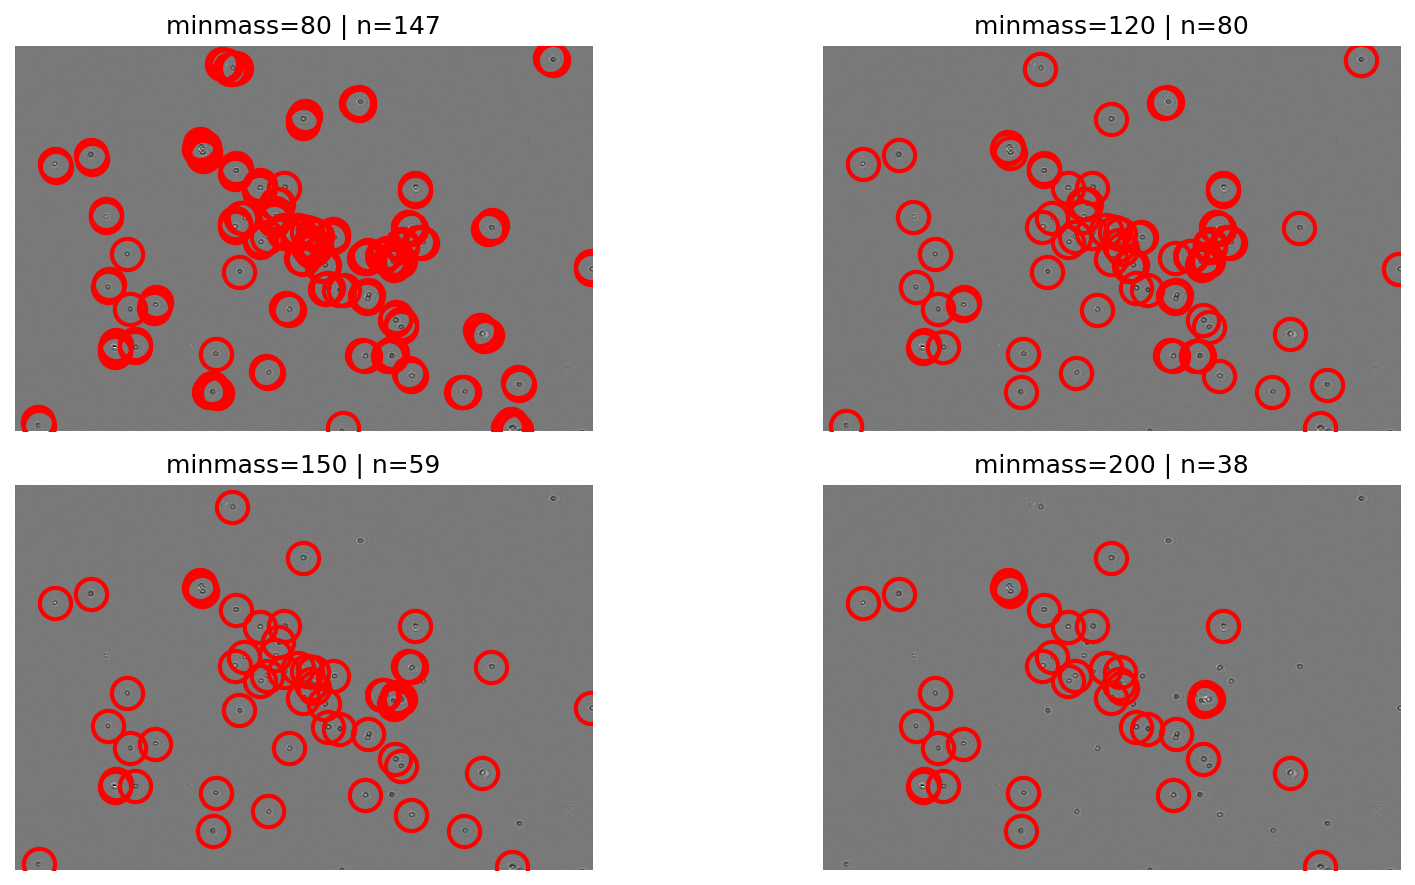

In [ ]:
frame_idx = -1
diam = CFG["locate"]["diameter"]
invert = CFG["locate"]["invert"]

minmass_list = [80, 120, 150, 200]  # cambia qui
n = len(minmass_list)
cols = 2
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 6), dpi=150)
axes = np.array(axes).reshape(-1)

for ax, mm in zip(axes, minmass_list):
    feats = tp.locate(framesN[frame_idx], diam, minmass=mm, invert=invert)
    ax.imshow(framesN[frame_idx], cmap="gray")
    tp.annotate(feats, framesN[frame_idx], ax=ax)
    ax.set_title(f"minmass={mm} | n={len(feats)}")
    ax.axis("off")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# output (timestamp)
stamp = datetime.now().strftime("%Y_%m_%d_%H%M%S")
h5_path = DATA_DIR / f"{VIDEO_PATH.stem}_{stamp}.h5"

# memory: default = “infinite”
memory = CFG["link"]["memory"]
if memory is None:
    memory = nFrames - 1

tp.quiet()

with tp.PandasHDFStoreBig(str(h5_path)) as s:
    tp.batch(
        framesN,                          # tutto in RAM
        CFG["locate"]["diameter"],
        minmass=CFG["locate"]["minmass"],
        invert=CFG["locate"]["invert"],
        processes="auto",
        engine="numba",
        output=s
    )

with tp.PandasHDFStoreBig(str(h5_path)) as s:
    for linked in tp.link_df_iter(
        s,
        search_range=CFG["link"]["search_range"],
        adaptive_stop=CFG["link"]["adaptive_stop"],
        adaptive_step=CFG["link"]["adaptive_step"],
        memory=memory
    ):
        s.put(linked)

print("Saved H5:", h5_path)

Saved H5: /home/user/Scrivania/Videos/December2023/Quantitative/forTraj/tAlgae68_2026_03_16_161509.h5


Trajectories before: 826
Trajectories after : 826


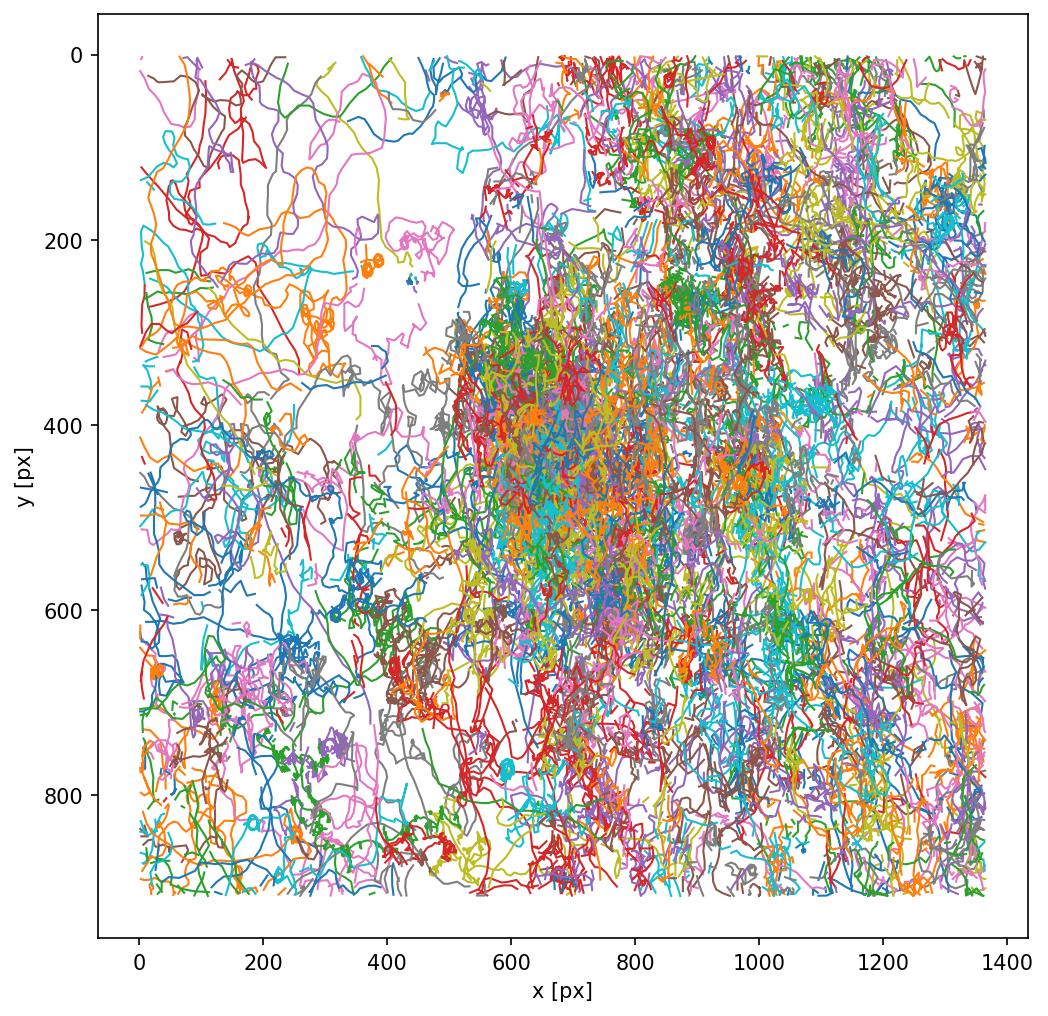

In [13]:
with tp.PandasHDFStoreBig(str(h5_path)) as s:
    t = pd.concat(iter(s), ignore_index=True)

t1 = tp.filter_stubs(t, CFG["post"]["filter_stubs"])

print("Trajectories before:", t["particle"].nunique())
print("Trajectories after :", t1["particle"].nunique())

plt.figure(figsize=(8, 8), dpi=150)
tp.plot_traj(t1, label=False)
plt.show()

In [16]:
CFG_OUT = dict(CFG)
CFG_OUT["video_example"] = str(VIDEO_PATH)
CFG_OUT["notes"] = f"Chosen on {stamp} using {VIDEO_NAME}"

#config_path = DATA_DIR / "config_tracking.json"
config_path = "/home/user/Scrivania/Videos/code-analysis/package_GV/video_test/tracking_from_video/configs/config_tracking.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(CFG_OUT, f, indent=2)

print("Saved config:", config_path)

Saved config: /home/user/Scrivania/Videos/code-analysis/package_GV/video_test/tracking_from_video/configs/config_tracking.json
